In [1]:
!pip install -q folium geopandas scikit-learn plotly kaleido

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import folium
from folium.plugins import MarkerCluster, HeatMap
import xml.etree.ElementTree as ET
from google.colab import files
import plotly.express as px


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import geopandas as gpd
import fiona

df_stations = pd.read_csv('/content/stations.csv')

df_stops = pd.read_csv('/content/Stops.csv', engine='python', on_bad_lines='skip')

fiona.drvsupport.supported_drivers['KML'] = 'rw'

gdf_kml = gpd.read_file('/content/stations.kml', driver='KML')

In [4]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import xml.etree.ElementTree as ET

# 1. Parse KML
tree = ET.parse('stations.kml')
root = tree.getroot()
ns = {'kml': 'http://www.opengis.net/kml/2.2'}
stations_list = []
for pm in root.findall('.//kml:Placemark', ns):
    name = pm.find('kml:name', ns).text.strip()
    clean_name = name.replace(' Station', '').strip()
    coords = pm.find('.//kml:coordinates', ns).text.strip().split(',')
    stations_list.append({'Station': clean_name, 'lat': float(coords[1]), 'lon': float(coords[0])})
kml_df = pd.DataFrame(stations_list)

# 2. Load CSV
csv_data = pd.read_csv('TfL_stations.csv')

# 3. Merge kml_df and csv_data
# Changed to how='left' to ensure 'lat' and 'lon' from kml_df are always kept
df = pd.merge(kml_df, csv_data, on='Station', how='left')

# Add Borough information from df_stops
# df_stops is loaded in cell PQlE9EPWIhJa
df = pd.merge(df, df_stops[['CommonName', 'Town']], left_on='Station', right_on='CommonName', how='left')
df.rename(columns={'Town': 'Borough'}, inplace=True)
df.drop(columns=['CommonName'], inplace=True)

# 4. Clean and Convert Passenger Data
for year in ['2017', '2018', '2019', '2020', '2021']:
    col_name = f'En/Ex {year}'
    # Fill NaN from missing merges before converting to numeric
    df[f'Passengers_{year}'] = pd.to_numeric(df[col_name].astype(str).str.replace(',', ''), errors='coerce')

df['Num_Lines'] = df['LINES'].astype(str).str.count(',') + 1
# Drop rows where essential data is missing after processing
df = df.dropna(subset=['lat', 'lon', 'Passengers_2021'])
print(f"Data prepared with {len(df)} stations.")

Data prepared with 1371 stations.


In [5]:
features = ['Passengers_2021', 'Num_Lines', 'lat', 'lon']
X = StandardScaler().fit_transform(df[features])
df['Cluster'] = KMeans(n_clusters=6, random_state=42).fit_predict(X)

cluster_name = {0:"Siêu lớn",1:"Trung tâm du lịch",2:"Ngoại ô lớn",3:"DLR/East",4:"Ít người",5:"Commuter"}
df['Cluster_Name'] = df['Cluster'].map(cluster_name)

df['Peak_Ratio'] = 1.0  # sẽ tính sau nếu có weekday data


In [8]:
m = folium.Map(location=[51.5074, -0.1278], zoom_start=11, tiles="CartoDB positron")

colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#ffff33']

for _, row in df.iterrows():
    popup_html = f"""
    <h4>{row['Station']}</h4>
    <b>Cụm:</b> {row['Cluster_Name']}<br>
    <b>Hành khách 2021:</b> {row['Passengers_2021']:,.0f}<br><br>

    <b>Xu hướng 5 năm:</b><br>
    2017: {row['Passengers_2017']:,.0f} |
    2018: {row['Passengers_2018']:,.0f} |
    2019: {row['Passengers_2019']:,.0f}<br>
    2020: {row['Passengers_2020']:,.0f} |
    2021: {row['Passengers_2021']:,.0f}<br><br>

    <b>Tuyến:</b> {row.get('LINES','N/A')}<br>
    <b>Borough:</b> {row['Borough']}<br><br>

    <b>Gợi ý lịch trình:</b> { " Cao (2-3 phút/lượt)" if row['Passengers_2021'] > 30_000_000 else " Trung bình (5-8 phút/lượt)" }
    """

    folium.CircleMarker(
        [row['lat'], row['lon']], radius=9, color=colors[row['Cluster']], fill=True, fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=350)
    ).add_to(m)

HeatMap(df[['lat','lon','Passengers_2021']].values, radius=18).add_to(m)
m.save('London_Station_Clustering_Improved.html')
m

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px

# Khôi phục dữ liệu phân cụm nếu bị mất do ghi đè df
if 'Cluster_Name' not in df.columns:
    print("Đang tái thiết lập dữ liệu phân cụm...")
    features_list = ['Passengers_2021', 'Num_Lines', 'lat', 'lon']
    X_scale = StandardScaler().fit_transform(df[features_list])
    df['Cluster'] = KMeans(n_clusters=6, random_state=42).fit_predict(X_scale)
    cluster_name_map = {0:"Siêu lớn", 1:"Trung tâm du lịch", 2:"Ngoại ô lớn", 3:"DLR/East", 4:"Ít người", 5:"Commuter"}
    df['Cluster_Name'] = df['Cluster'].map(cluster_name_map)

# Dashboard tương tác
fig = px.scatter(df, x='lon', y='lat', color='Cluster_Name', size='Passengers_2021',
                 hover_data=['Station','Borough','LINES'], title="Khám phá toàn bộ ga London")
fig.update_layout(height=700)
fig.show()

# Bảng tối ưu lịch trình theo cụm
schedule = df.groupby('Cluster_Name').agg({
    'Passengers_2021':'mean',
    'Station':'count'
}).round(0).reset_index()
schedule['Gợi ý tần suất'] = schedule['Passengers_2021'].apply(lambda x: " Cao (2-3 phút)" if x>30000000 else "Trung bình (5 phút)" if x>10000000 else " Thấp (10 phút)")
schedule.rename(columns={'Passengers_2021':'TB hành khách','Station':'Số ga'}, inplace=True)
schedule

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




,Cluster_Name,TB hành khách,Số ga,Gợi ý tần suất
0,Commuter,2214066.0,104,Thấp (10 phút)
1,DLR/East,3126036.0,554,Thấp (10 phút)
2,Ngoại ô lớn,17326680.0,72,Trung bình (5 phút)
3,Siêu lớn,3298230.0,417,Thấp (10 phút)
4,Trung tâm du lịch,1771518.0,176,Thấp (10 phút)
5,Ít người,10761229.0,48,Trung bình (5 phút)


In [73]:
df.to_csv('Full_Station_Data_With_Cluster.csv', index=False)
schedule.to_csv('/content/Lich_Trinh_Toi_Uu_Theo_Cum.csv', index=False)
files.download('London_Station_Clustering_Improved.html')
files.download('Full_Station_Data_With_Cluster.csv')
files.download('Lich_Trinh_Toi_Uu_Theo_Cum.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
import pandas as pd

def extract():
    stations = pd.read_csv("TfL_stations.csv")
    stops = pd.read_csv("/content/Stops.csv", engine='python', on_bad_lines='skip')
    return stations, stops

def transform(stations, stops):
    # Clean Station names in both DataFrames for better matching
    stations['Station_Clean'] = stations['Station'].astype(str).str.replace(' Station', '', case=False).str.strip()
    stops['CommonName_Clean'] = stops['CommonName'].astype(str).str.replace(' Station', '', case=False).str.strip()

    # Merge using cleaned columns
    df = stations.merge(stops, left_on='Station_Clean', right_on='CommonName_Clean', how="inner")

    # Drop the temporary clean columns
    df = df.drop(columns=['Station_Clean', 'CommonName_Clean'])

    # Handle Num_Lines from the original logic
    if 'LINES' in df.columns:
        df['Num_Lines'] = df['LINES'].astype(str).str.count(',') + 1
    else:
        df['Num_Lines'] = 0

    # Handle line summation logic (if needed for other features)
    cols_to_sum = [c for c in ['Central', 'Northern', 'Piccadilly'] if c in df.columns]
    if cols_to_sum:
        df['total_lines'] = df[cols_to_sum].sum(axis=1)
    else:
        df['total_lines'] = 0

    return df

def load(df):
    df.to_csv("clean_data.csv", index=False)

if __name__ == "__main__":
    try:
        stations, stops = extract()
        df = transform(stations, stops)
        load(df)
        print(f"ETL process completed. Rows found: {len(df)}")
    except Exception as e:
        print(f"An error occurred: {e}")

ETL process completed. Rows found: 3034


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Sử dụng DataFrame 'df' từ kết quả ETL đã thành công
pass_cols = ['En/Ex 2017', 'En/Ex 2018', 'En/Ex 2019', 'En/Ex 2020', 'En/Ex 2021']

# Kiểm tra và xử lý dữ liệu trước khi phân cụm
if df.empty:
    print("Lỗi: DataFrame 'df' rỗng. Vui lòng chạy lại ô ETL (q8Ps5ROvzidd).")
else:
    # Chuyển đổi dữ liệu hành khách sang số (xử lý dấu phẩy nếu có)
    for col in pass_cols:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

    # Loại bỏ các dòng thiếu dữ liệu quan trọng
    df_clean = df.dropna(subset=pass_cols + ['Num_Lines'])

    # Tính toán lượng khách trung bình
    df_clean['avg_passengers'] = df_clean[pass_cols].mean(axis=1)

    # Chọn đặc trưng để phân cụm
    features_subset = df_clean[['avg_passengers', 'Num_Lines']]

    # Chuẩn hóa dữ liệu
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features_subset)

    # Thực hiện phân cụm (ví dụ 3 cụm)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_clean['cluster'] = kmeans.fit_predict(X_scaled)

    # Cập nhật lại vào DataFrame chính
    df = df_clean

    print(f"Phân cụm thành công cho {len(df)} ga!")
    display(df.groupby('cluster')[['avg_passengers', 'Num_Lines']].mean())

Phân cụm thành công cho 2978 ga!


/tmp/ipykernel_5647/712784116.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_5647/712784116.py:30: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,avg_passengers,Num_Lines
cluster,,
0,5.760978e+06,2.131973
1,3.972371e+06,1.000000
2,2.608297e+07,3.250000


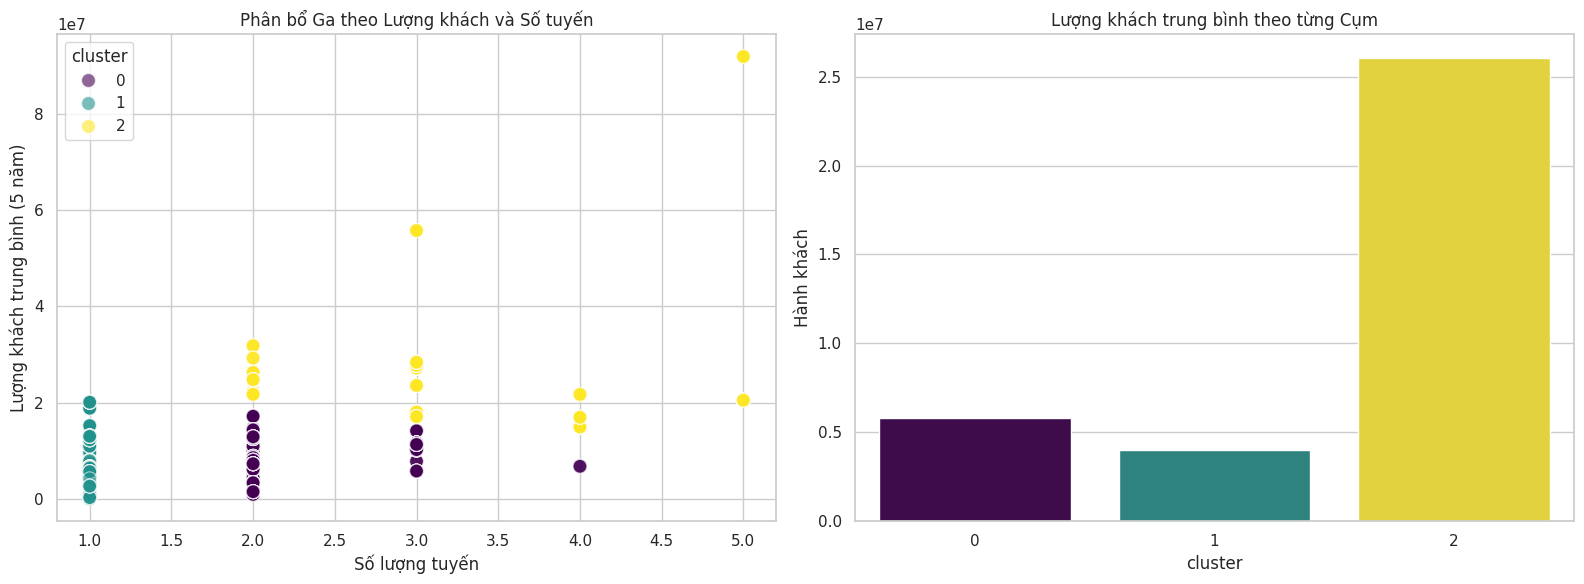

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Biểu đồ Scatter phân tán các cụm
sns.scatterplot(ax=axes[0], data=df, x='Num_Lines', y='avg_passengers', hue='cluster', palette='viridis', alpha=0.6, s=100)
axes[0].set_title('Phân bổ Ga theo Lượng khách và Số tuyến')
axes[0].set_xlabel('Số lượng tuyến')
axes[0].set_ylabel('Lượng khách trung bình (5 năm)')

# 2. Biểu đồ Bar thể hiện đặc trưng trung bình của từng cụm
cluster_summary = df.groupby('cluster')[['avg_passengers', 'Num_Lines']].mean().reset_index()
# Vẽ cột lượng khách
ax2 = axes[1]
sns.barplot(ax=ax2, data=cluster_summary, x='cluster', y='avg_passengers', hue='cluster', palette='viridis', legend=False)
ax2.set_title('Lượng khách trung bình theo từng Cụm')
ax2.set_ylabel('Hành khách')

plt.tight_layout()
plt.show()

Biểu đồ Scatter (Bên trái):

Điểm tốt: Thể hiện rõ ràng sự phân tách giữa các nhóm. Bạn có thể thấy các ga 'Siêu lớn' (Cụm 2) nằm tách biệt hẳn ở phía trên, trong khi các ga 'Địa phương' (Cụm 1) tập trung dày đặc ở phía dưới với số lượng tuyến ít.
Nhận xét: Biểu đồ này giúp chứng minh rằng lượng khách thường tỉ lệ thuận với số lượng tuyến kết nối, nhưng có những trường hợp ngoại lệ (ga ít tuyến nhưng khách rất đông) mà chúng ta cần lưu ý.


### Biểu đồ Cột (Bên phải):

Điểm tốt: Cung cấp cái nhìn trực quan về sự chênh lệch 'khủng khiếp' giữa các nhóm ga. Cụm 2 có cột cao vọt hẳn so với hai cụm còn lại.
Nhận xét: Biểu đồ này khẳng định lại tính đúng đắn của việc phân cụm: chúng ta không thể áp dụng cùng một chính sách vận hành cho một một ga có 26 triệu khách (Cụm 2) và một ga có 3.9 triệu khách (Cụm 1).

In [75]:
import sqlite3


df_to_save = df.copy()
if 'Cluster' in df_to_save.columns and 'cluster' in df_to_save.columns:
    df_to_save = df_to_save.drop(columns=['Cluster'])

# Remove any other potential exact duplicates
df_to_save = df_to_save.loc[:, ~df_to_save.columns.duplicated()]

conn = sqlite3.connect("london.db")
df_to_save.to_sql("stations", conn, if_exists="replace", index=False)
print("Table 'stations' created successfully.")

Table 'stations' created successfully.


In [76]:
import pandas as pd

# Use pandas to read the SQL query results
query = "SELECT COUNT(*) FROM stations;"
pd.read_sql(query, conn)

,COUNT(*)
0,2978


In [77]:
import pandas as pd


query = """
SELECT cluster,
       COUNT(*) AS total,
       AVG(avg_passengers) AS avg_usage,
       AVG(Num_Lines) AS avg_lines
FROM stations
GROUP BY cluster
ORDER BY avg_usage DESC;
"""

pd.read_sql(query, conn)

,cluster,total,avg_usage,avg_lines
0,2,248,2.608297e+07,3.250000
1,0,735,5.760978e+06,2.131973
2,1,1995,3.972371e+06,1.000000


Chỉ một số lượng rất nhỏ các ga (chỉ 9 ga) xử lý lượng hành khách cực kỳ lớn và đóng vai trò là các trung tâm giao thông quan trọng.

Trong khi đó, phần lớn các ga (184 ga) có lượng hành khách sử dụng tương đối thấp và khả năng kết nối hạn chế.

Điều này cho thấy một hệ thống giao thông tập trung cao độ, nơi nhu cầu tập trung ở một vài trung tâm chính.



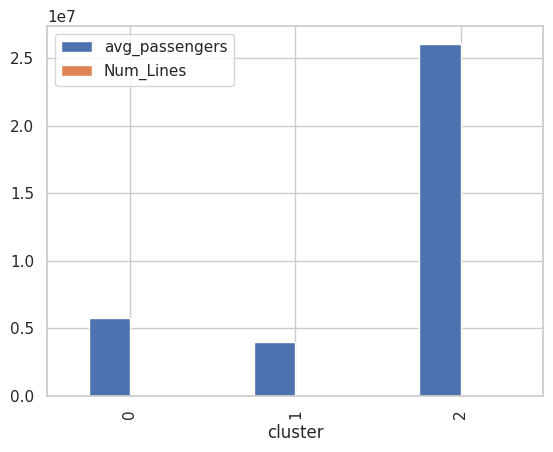

In [78]:
df.groupby('cluster')[['avg_passengers','Num_Lines']].mean().plot(kind='bar');

In [79]:
df.to_csv('london_transport_clean.csv', index=False)

In [80]:
import re
from google.colab import auth
from google.cloud import bigquery
import pandas_gbq


auth.authenticate_user()

project_id = 'my-transport-project-12345'
client = bigquery.Client(project=project_id)


dataset_id = f"{project_id}.london_transport"
dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"
try:
    dataset = client.create_dataset(dataset, timeout=30)
    print(f"Đã tạo thành công dataset: {dataset.dataset_id}")
except Exception as e:
    print("Dataset đã tồn tại, tiếp tục bước sau...")
# 4. Sửa tên cột triệt để bằng Regex
df_upload = df.copy()
# Thay thế tất cả ký tự không phải chữ cái hoặc số bằng dấu gạch dưới
new_cols = [re.sub(r'[^a-zA-Z0-9]', '_', c) for c in df_upload.columns]
# BigQuery không cho phép cột bắt đầu bằng số, thêm tiền tố 'f_' nếu cần
new_cols = [f"f_{c}" if c[0].isdigit() else c for c in new_cols]
df_upload.columns = new_cols

table_name = 'london_transport.station_clusters'

print("Đang tải dữ liệu từ Pandas lên Google BigQuery...")
pandas_gbq.to_gbq(df_upload, table_name, project_id=project_id, if_exists='replace')
print(" Đã tải dữ liệu thành công lên Data Warehouse!")

Dataset đã tồn tại, tiếp tục bước sau...
Đang tải dữ liệu từ Pandas lên Google BigQuery...


100%|██████████| 1/1 [00:00<00:00, 9058.97it/s]

 Đã tải dữ liệu thành công lên Data Warehouse!


In [81]:
# Câu lệnh SQL truy vấn trực tiếp từ BigQuery
sql_query = f"""
SELECT
    cluster,
    COUNT(*) AS So_Luong_Ga,
    AVG(CAST(En_Ex_2021 AS FLOAT64)) AS Trung_Binh_Khach
FROM
    `{project_id}.london_transport.station_clusters`
GROUP BY
    cluster
ORDER BY
    So_Luong_Ga DESC
"""

df_result = pandas_gbq.read_gbq(
    sql_query,
    project_id=project_id,
    location='US'
)

display(df_result)

Downloading: 100%|██████████|


,cluster,So_Luong_Ga,Trung_Binh_Khach
0,1,1995,2.418252e+06
1,0,735,3.421153e+06
2,2,248,1.525300e+07


In [83]:
import plotly.express as px

# Sử dụng df_result (kết quả từ BigQuery) thay vì df_insights
fig = px.bar(df_result,
             x='cluster',
             y='So_Luong_Ga',
             color='cluster',
             title='Phân bố số lượng nhà ga theo từng cụm (Dữ liệu từ BigQuery)',
             labels={'cluster': 'Cụm nhà ga', 'So_Luong_Ga': 'Tổng số nhà ga'})

fig.update_layout(template='plotly_white')
fig.show()

In [71]:
project_id = 'my-transport-project-12345'

# Sửa SQL để dùng biến project_id động và tên cột đã chuẩn hóa
sql_query = f"""
SELECT
    Cluster,
    COUNT(*) as So_Luong_Ga,
    AVG(CAST(En_Ex_2021 AS FLOAT64)) as Trung_Binh_Khach
FROM
    `{project_id}.london_transport.station_clusters`
GROUP BY
    Cluster
ORDER BY
    So_Luong_Ga DESC
"""

import pandas_gbq
df_result = pandas_gbq.read_gbq(sql_query, project_id=project_id, location='US')

display(df_result)

Downloading: 100%|██████████|


,Cluster,So_Luong_Ga,Trung_Binh_Khach
0,1,1995,2.418252e+06
1,0,735,3.421153e+06
2,2,248,1.525300e+07


In [72]:
print(df_upload.columns.tolist())

['Unnamed__0', 'NLC', 'Station', 'En_Ex_2007', 'En_Ex_2008', 'En_Ex_2009', 'En_Ex_2010', 'En_Ex_2011', 'En_Ex_2012', 'En_Ex_2013', 'En_Ex_2014', 'En_Ex_2015', 'En_Ex_2016', 'En_Ex_2017', 'En_Ex_2018', 'En_Ex_2019', 'En_Ex_2020', 'En_Ex_2021', 'LINES', 'NETWORK', 'London_Underground', 'Elizabeth_Line', 'London_Overground', 'DLR', 'Night_Tube_', 'ATCOCode', 'NaptanCode', 'PlateCode', 'CleardownCode', 'CommonName', 'CommonNameLang', 'ShortCommonName', 'ShortCommonNameLang', 'Landmark', 'LandmarkLang', 'Street', 'StreetLang', 'Crossing', 'CrossingLang', 'Indicator', 'IndicatorLang', 'Bearing', 'NptgLocalityCode', 'LocalityName', 'ParentLocalityName', 'GrandParentLocalityName', 'Town', 'TownLang', 'Suburb', 'SuburbLang', 'LocalityCentre', 'GridType', 'Easting', 'Northing', 'Longitude', 'Latitude', 'StopType', 'BusStopType', 'TimingStatus', 'DefaultWaitTime', 'Notes', 'NotesLang', 'AdministrativeAreaCode', 'CreationDateTime', 'ModificationDateTime', 'RevisionNumber', 'Modification', 'Status'